MeaningFull Business Questions

1. Which product categories generate the highest sales?
2. Which categories generate the highest profit?
Does higher discount lead to lower profit?
3. Which states contribute the most sales and profit?
4. Which regions perform best and worst?
5. Which customer segment generates maximum revenue?
6. Which products are causing losses?
7. Are there any outliers in Sales or Profit?
8. Which sub-categories have high sales but low profit?
9. What trends can be observed in orders over time?

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [42]:
df.shape

(9994, 21)

In [43]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [44]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [45]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [46]:
print("Total Missing Values =", df.isnull().sum().sum())

Total Missing Values = 0


In [47]:
print("Duplicate Rows =", df.duplicated().sum())

Duplicate Rows = 0


In [48]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


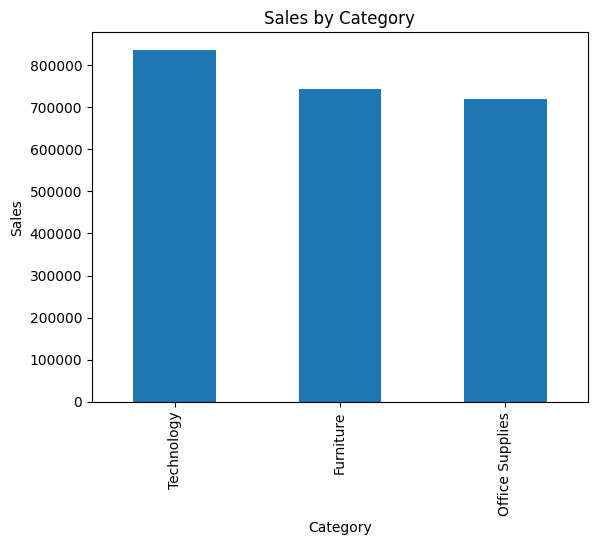

In [49]:
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [50]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


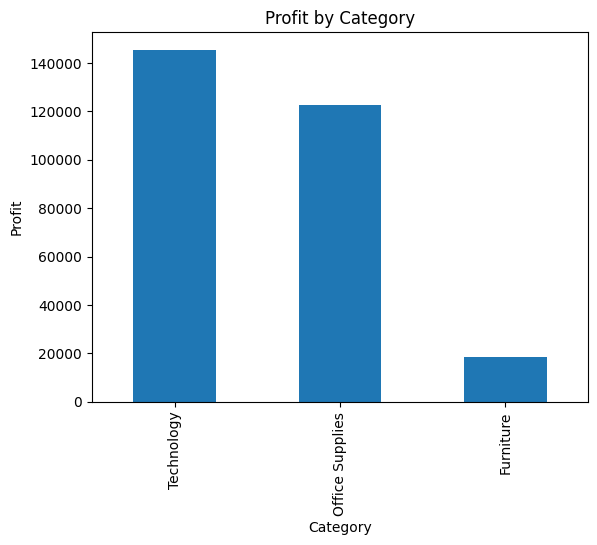

In [51]:
category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [52]:
region_analysis = df.groupby('Region')[['Sales','Profit']].sum()

region_analysis

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


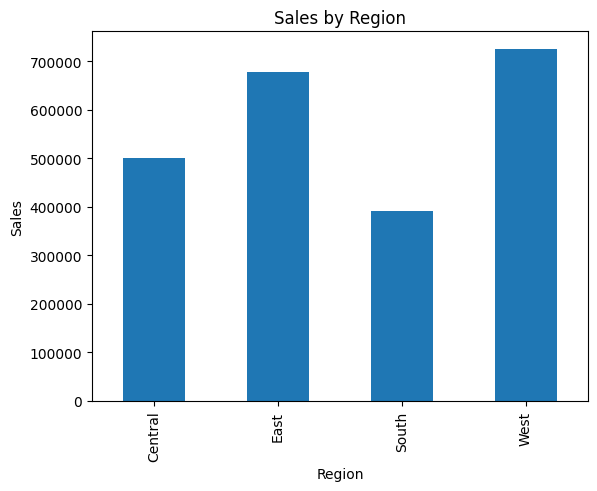

In [53]:
region_analysis['Sales'].plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

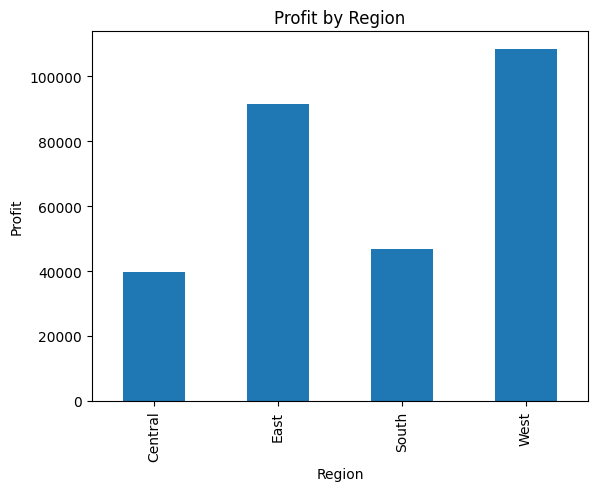

In [54]:
region_analysis['Profit'].plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [55]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


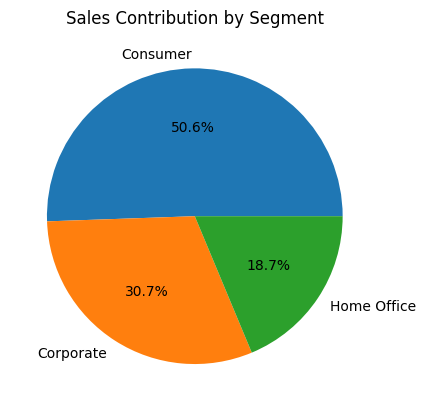

In [56]:
segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sales Contribution by Segment")
plt.ylabel("")

plt.show()

In [57]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


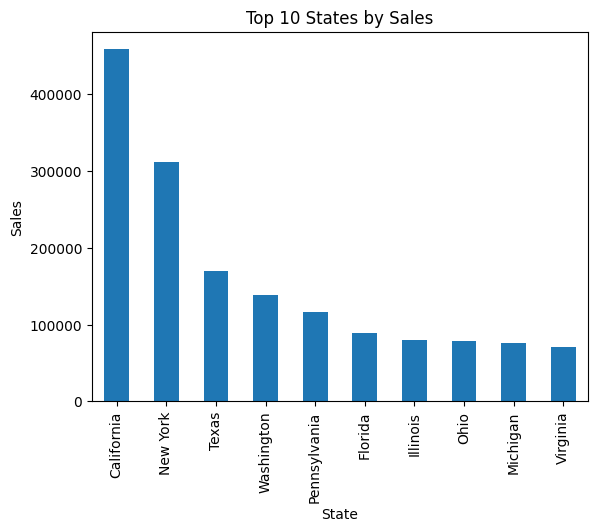

In [58]:
state_sales.head(10).plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

In [59]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

sub_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


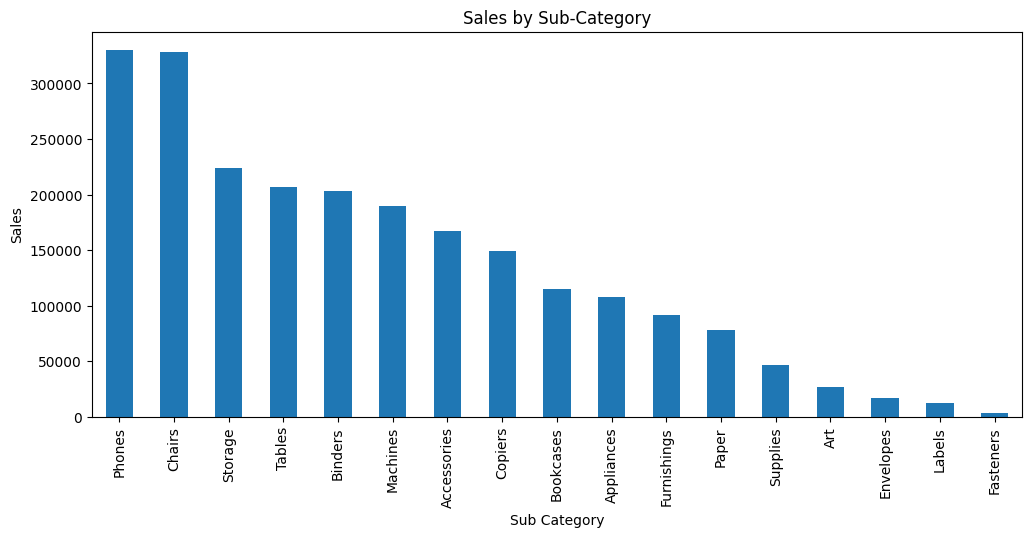

In [60]:
sub_sales.plot(kind='bar', figsize=(12,5))

plt.title("Sales by Sub-Category")
plt.xlabel("Sub Category")
plt.ylabel("Sales")

plt.show()

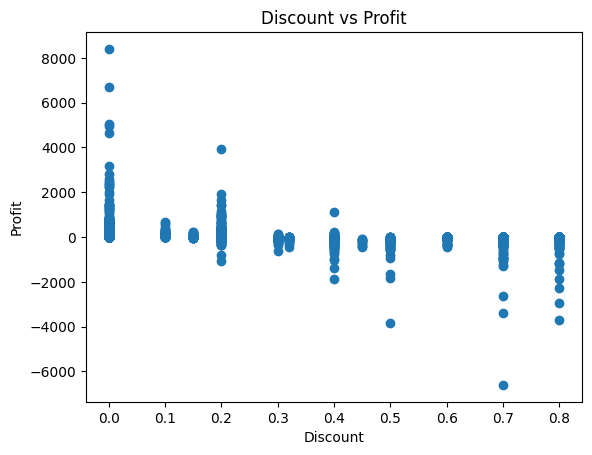

In [61]:
plt.scatter(df['Discount'], df['Profit'])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [62]:
corr = df[['Sales','Profit','Quantity','Discount']].corr()

corr

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479064,0.200795,-0.028190
Profit,0.479064,1.000000,0.066253,-0.219487
Quantity,0.200795,0.066253,1.000000,0.008623
Discount,-0.028190,-0.219487,0.008623,1.000000


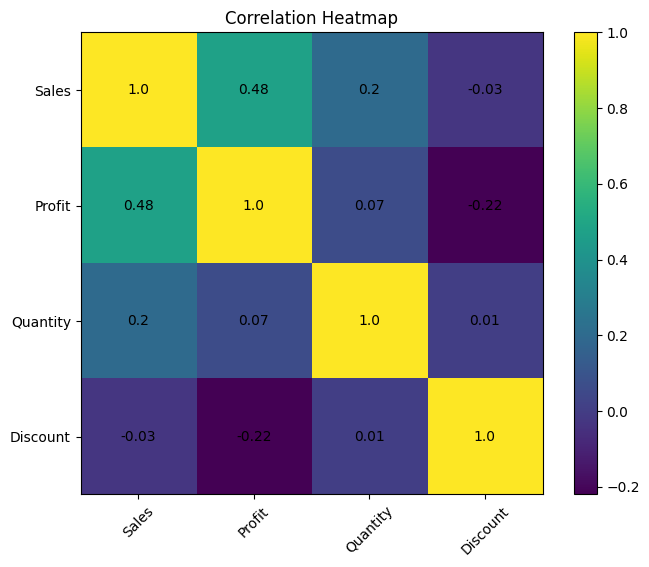

In [63]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i,
                 round(corr.iloc[i,j],2),
                 ha='center',
                 va='center')

plt.title("Correlation Heatmap")

plt.show()

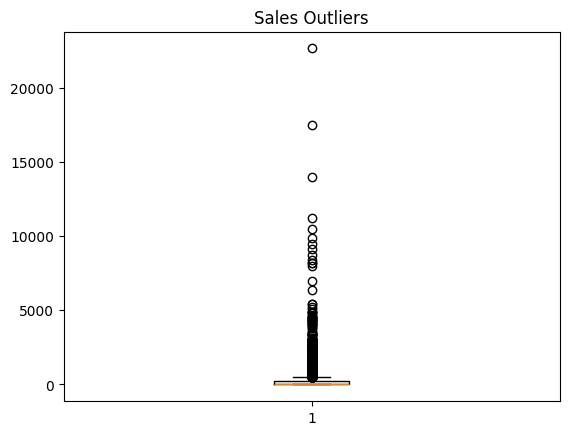

In [64]:
plt.boxplot(df['Sales'])

plt.title("Sales Outliers")

plt.show()

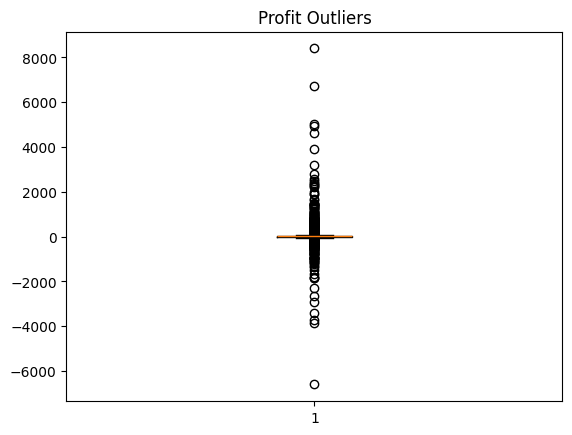

In [65]:
plt.boxplot(df['Profit'])

plt.title("Profit Outliers")

plt.show()

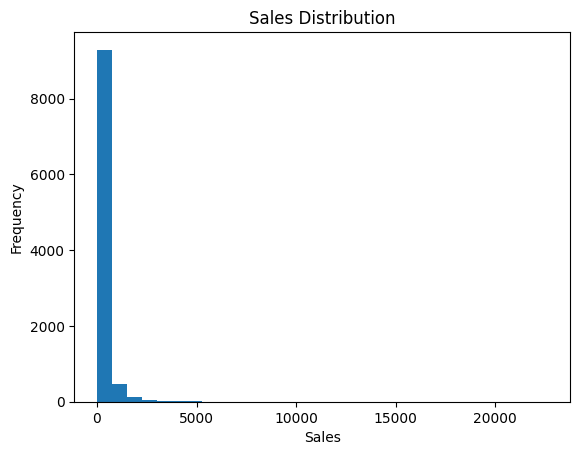

In [66]:
plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

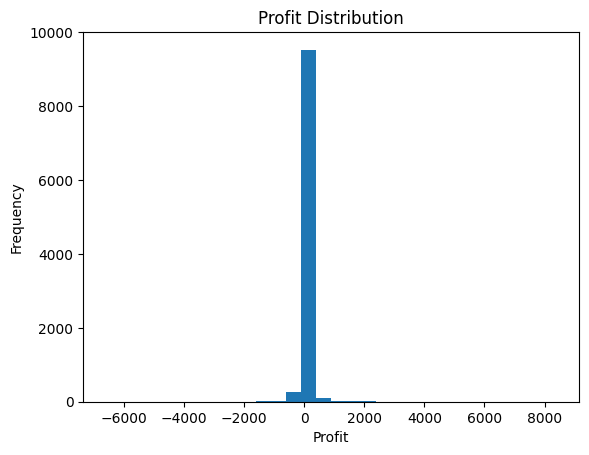

In [67]:
plt.hist(df['Profit'], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

In [68]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

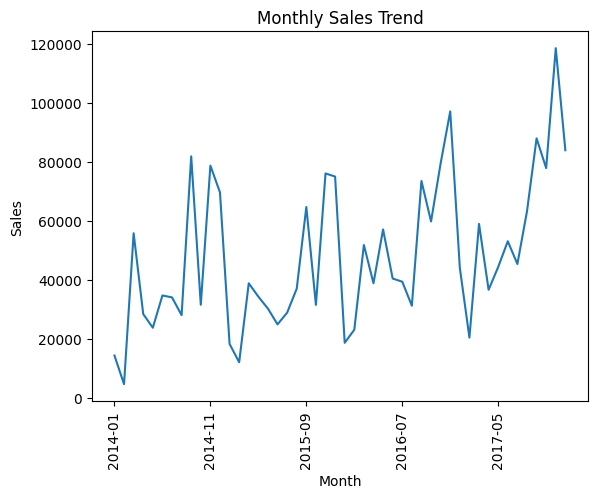

In [69]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

In [70]:
loss_products = df[df['Profit'] < 0]

loss_products[['Sub-Category','Sales','Profit']].head()

,Sub-Category,Sales,Profit
3,Tables,957.5775,-383.0310
14,Appliances,68.8100,-123.8580
15,Binders,2.5440,-3.8160
23,Chairs,71.3720,-1.0196
27,Bookcases,3083.4300,-1665.0522


In [71]:
loss_products.groupby('Sub-Category')['Profit'].sum().sort_values()

,Profit
Sub-Category,
Binders,-38510.4964
Tables,-32412.1483
Machines,-30118.6682
Bookcases,-12152.2060
Chairs,-9880.8413
Appliances,-8629.6412
Phones,-7530.6235
Furnishings,-6490.9134
Storage,-6426.3038


Business Answers

1. Technology generated the highest sales.
2. Consumer segment contributed the most revenue.
3. Higher discounts negatively impacted profit.
4. Several outliers were found in Sales and Profit.
5. Some sub-categories generated losses.
6. Sales showed fluctuations over time.
7. Dataset contained minimal data quality issues.